In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix)
    
os.chdir(r'C:\Users\DAY\Desktop\DIPLOMADO_ANALISIS_DE_DATOS')

df=pd.read_csv("bank-additional-full.csv", sep=';')

In [17]:
df.head(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [18]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [19]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [20]:
#Eliminamos variables no necesarias
df = df.drop(columns=["duration"], errors="ignore")

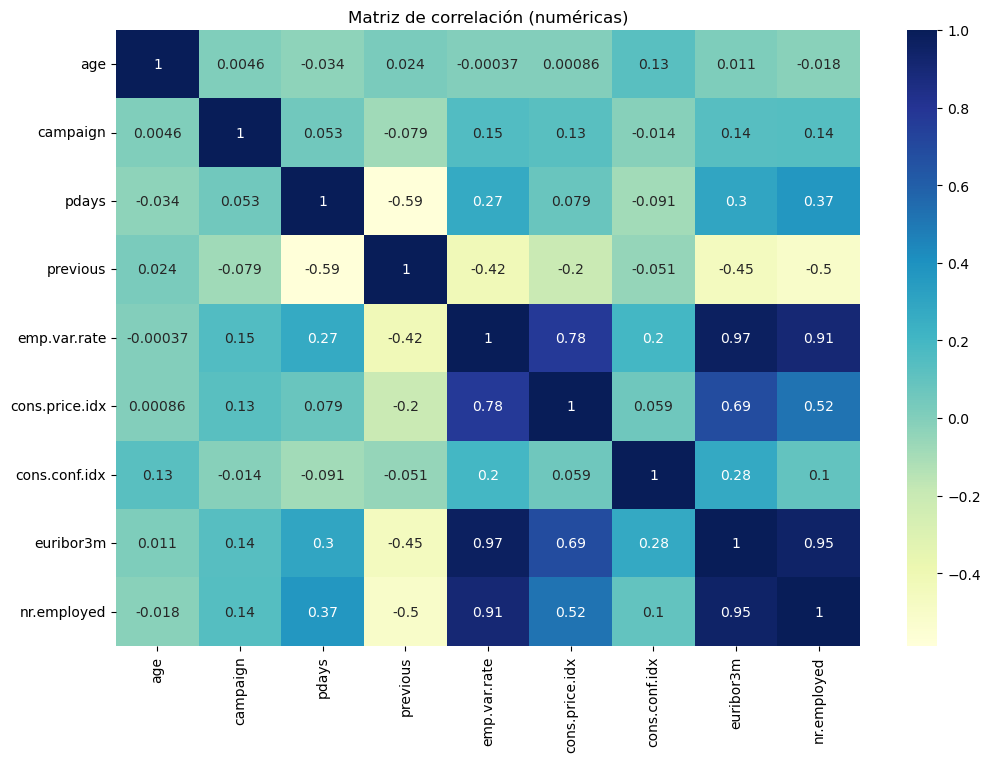

In [22]:
#Quitamos variables con alta correlación
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr(method="pearson")

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="YlGnBu", annot=True)
plt.title("Matriz de correlación (numéricas)")
plt.show()

In [23]:
threshold = 0.90
corr_abs = corr.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
to_drop

['euribor3m', 'nr.employed']

In [24]:
df = df.drop(columns=to_drop, errors="ignore")
df.shape

(41188, 18)

In [25]:
X = df.drop(columns=["y"])
y = df["y"].map({"no": 0, "yes": 1})

In [26]:
X = pd.get_dummies(X, drop_first=True)
X.shape

(41188, 50)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.30, random_state=1, stratify=y)

In [30]:
model= LogisticRegression(class_weight={0:0.15, 1:0.85}, solver="liblinear")
model.fit(X_train, y_train)

y_predict= model.predict(X_test)

In [32]:
cm = confusion_matrix(y_test, y_predict, labels=[1,0])
cm

array([[ 844,  548],
       [1319, 9646]])

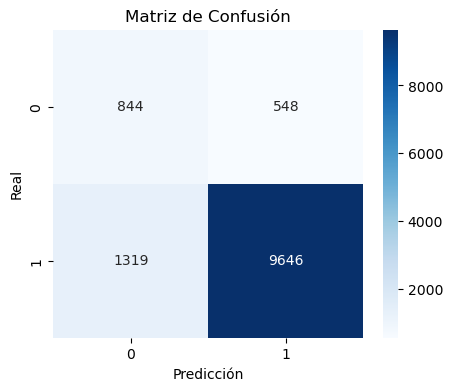

In [33]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

In [34]:
y_pred=model.predict(X_test)
model_score=accuracy_score(y_test, y_pred)
recall_score=recall_score(y_test, y_pred)
precision_score= precision_score(y_test, y_pred)
f1_score= f1_score(y_test, y_pred)

print("Medidas del Modelo")
print("----------------")
print("Accuracy = {0:0.2f}".format(model_score))
print("Precision = {0:0.2f}".format(precision_score))
print("Recall = {0:0.2f}".format(recall_score))
print("F1 Score = {0:0.2f}".format(f1_score))
print("Roc Auc Score = {0:0.2f}".format(roc_auc_score(y_test, y_pred)))

Medidas del Modelo
----------------
Accuracy = 0.85
Precision = 0.39
Recall = 0.61
F1 Score = 0.47
Roc Auc Score = 0.74


## Conclusión
- El modelo de regresión logística obtuvo una accuracy de 0.85, lo que indica un buen nivel general de predicción. Sin embargo, la precision (0.39) muestra que no todos los clientes predichos como interesados realmente lo estaban. El recall (0.61) indica que el modelo logra identificar una parte importante de los clientes que sí responden a la campaña. En general, el modelo tiene un desempeño aceptable y puede servir como una primera aproximación para identificar posibles clientes interesados.